# Bloch ED: MoTe2 three-band momentum-resolved many-body spectrum

This notebook mirrors the Haldane Bloch-ED workflow for the MoTe2 three-orbital model.

Interaction convention in this notebook:
- `V1` is a density-density interaction on **true geometric nearest-neighbor site pairs** from the real-space embedding shown in the MoTe2 single-particle notebook (`MM@R`, `MX@R+u0`, `XM@R-u0`).
- Periodic minimum-image distance is used to define nearest neighbors on the finite torus.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aidan_custom.bloch_ed import (
    build_mote2_three_orbital_lattice_embedding,
    build_mote2_three_orbital_projected_hamiltonian,
    build_mote2_three_orbital_supercell_bravais_positions,
    build_mote2_three_orbital_supercell_k_mesh,
    build_mote2_three_orbital_supercell_vectors,
    solve_projected_all_momentum_sectors,
)
from aidan_custom.geometry import (
    first_bz_hexagon_vertices,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    sample_shortest_representative_bz,
)
from aidan_custom.mote2_three_orbital import (
    mote2_three_orbital_bloch_hamiltonian,
    mote2_three_orbital_berry_and_metric_trace,
    mote2_three_orbital_reciprocal_vectors,
)

In [26]:
# Model and ED parameters
supercell_matrix = np.array([[3, 0], [0, 3]], dtype=np.int64)

#np.array([[3, 6], [-3, 3]], dtype=np.int64) #27 site

n_particles = 3
selected_bands = [0]

# # Eq. (2) parameters from Fig. 3b at theta = 3 deg (meV)
# delta = 27.9
# ez = 0.0
# t_th1 = 5.15
# t_hh1 = 1.81
# t_th2 = 0.07
# t_hh3 = 0.43
# t_tt1 = -0.46
# a_m = 1.0
# ph_conj = True

# Ideal band optimized parameters
delta = 5.426542963374432
ez = 0.0
t_th1 = 1.
t_hh1 = 0.4689334070165771
t_th2 = -0.07151471515876148
t_hh3 = 0.037340187144172164
t_tt1 = -0.0377535889269079
a_m = 1.0
ph_conj = True

#uniform geometry optimize parameters
# delta=3.82706508
# ez = 0.
# t_th1 = 1.
# t_hh1=0.42578321
# t_th2=-0.07361062
# t_hh3=0.06297999
# t_tt1=-0.03302708
# a_m=1.
# ph_conj= True

# Nearest-neighbor interaction on true geometric nearest-neighbor site pairs
V1 = 0.3

# Diagonalization policy
sparse_threshold = 100
n_eigs_dense = 8
n_eigs_sparse = 20


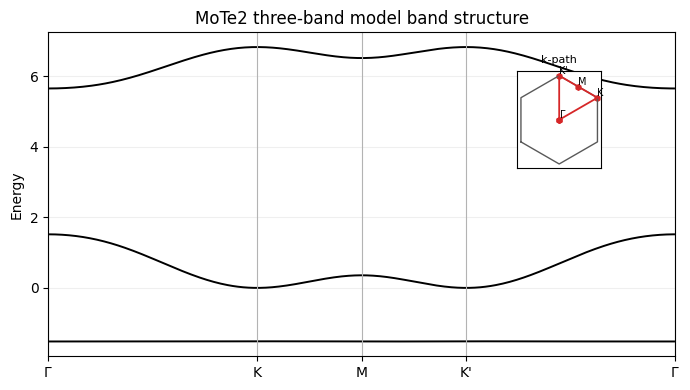

Estimated Chern number (band 0) = -1.0000000000
Estimated quantum weight (band 0) = 1.0019572060


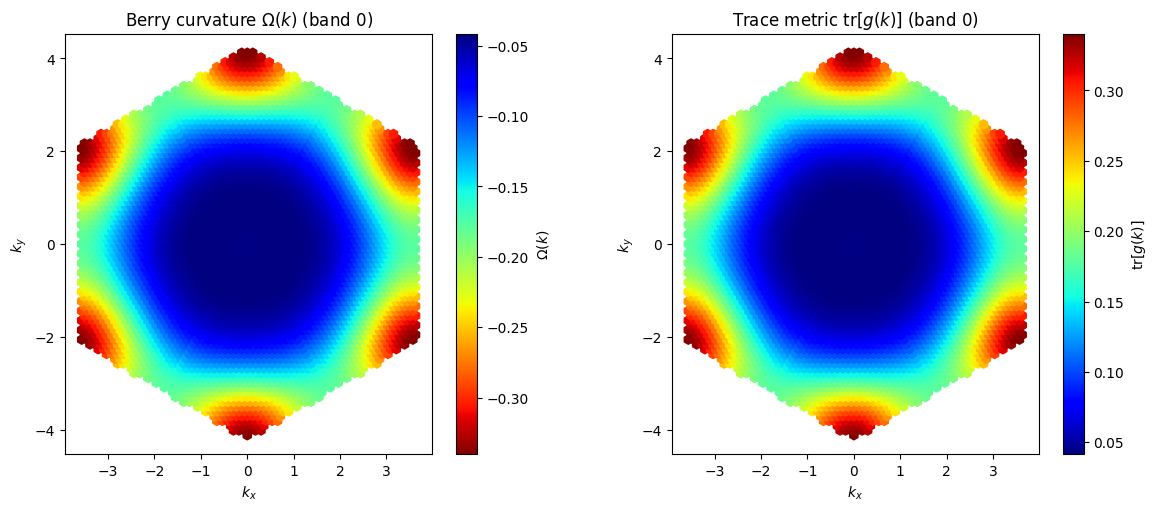

Canonical momentum-grid shape used internally: (3, 3)
Bravais unit cells in tilted supercell: 9
Supercell matrix (columns are L1 and L2 in the {a1, a2} basis):
[[3 0]
 [0 3]]


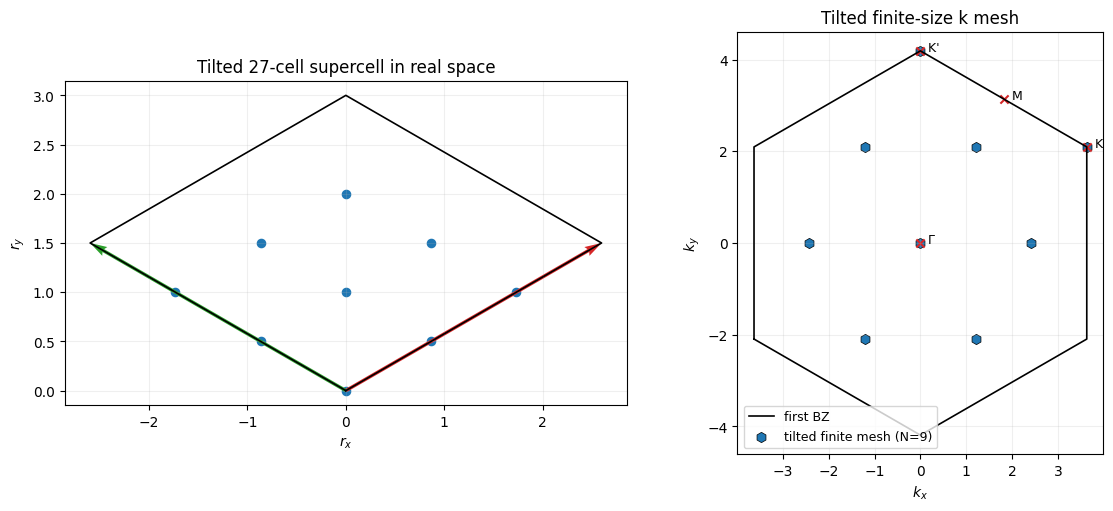

In [27]:
# Single-particle diagnostics: band structure + BZ geometry + Berry/QGT maps
b1, b2 = mote2_three_orbital_reciprocal_vectors(a_m=a_m)

# 1) Band structure along high-symmetry path
k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array(
    [
        np.linalg.eigvalsh(
            mote2_three_orbital_bloch_hamiltonian(
                kx=float(kx),
                ky=float(ky),
                delta=delta,
                ez=ez,
                t_th1=t_th1,
                t_hh1=t_hh1,
                t_th2=t_th2,
                t_hh3=t_hh3,
                t_tt1=t_tt1,
                a_m=a_m,
                ph_conj=ph_conj,
            )
        )
        for kx, ky in k_points
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black", lw=1.4)
ax.plot(x, bands[:, 1], color="black", lw=1.4)
ax.plot(x, bands[:, 2], color="black", lw=1.4)
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("MoTe2 three-band model band structure")
ax.grid(axis="y", alpha=0.2)

gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
bz_hex = first_bz_hexagon_vertices(b1, b2)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])

ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()

# 2) Berry curvature / metric trace and finite-mesh integral estimate
band_for_geometry = int(selected_bands[0])
_, kK, _, _ = high_symmetry_points(b1, b2)
omega_K, tr_g_K = mote2_three_orbital_berry_and_metric_trace(
    kK[0],
    kK[1],
    band=band_for_geometry,
    delta=delta,
    ez=ez,
    t_th1=t_th1,
    t_hh1=t_hh1,
    t_th2=t_th2,
    t_hh3=t_hh3,
    t_tt1=t_tt1,
    a_m=a_m,
    ph_conj=ph_conj,
)

Lx_bz_plot = 61
Ly_bz_plot = Lx_bz_plot
k_bz_all = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False)

berry_all = np.empty(k_bz_all.shape[0], dtype=float)
trg_all = np.empty(k_bz_all.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz_all):
    omega, trg = mote2_three_orbital_berry_and_metric_trace(
        kx,
        ky,
        band=band_for_geometry,
        delta=delta,
        ez=ez,
        t_th1=t_th1,
        t_hh1=t_hh1,
        t_th2=t_th2,
        t_hh3=t_hh3,
        t_tt1=t_tt1,
        a_m=a_m,
        ph_conj=ph_conj,
    )
    berry_all[i] = omega
    trg_all[i] = trg

area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
n_k = Lx_bz_plot * Ly_bz_plot
dk_area = area_bz / n_k
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = dk_area * np.sum(trg_all) / (2.0 * np.pi)
print(f"Estimated Chern number (band {band_for_geometry}) = {chern_number:.10f}")
print(f"Estimated quantum weight (band {band_for_geometry}) = {quantum_weight:.10f}")

k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=True)
berry_bz = np.empty(k_bz.shape[0], dtype=float)
trg_bz = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    omega, trg = mote2_three_orbital_berry_and_metric_trace(
        kx,
        ky,
        band=band_for_geometry,
        delta=delta,
        ez=ez,
        t_th1=t_th1,
        t_hh1=t_hh1,
        t_th2=t_th2,
        t_hh3=t_hh3,
        t_tt1=t_tt1,
        a_m=a_m,
        ph_conj=ph_conj,
    )
    berry_bz[i] = omega
    trg_bz[i] = trg

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
sc0 = axes[0].scatter(k_bz[:, 0], k_bz[:, 1], s=45, c=berry_bz, cmap="jet_r", marker="h")
axes[0].set_title(rf"Berry curvature $\Omega(k)$ (band {band_for_geometry})")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
axes[0].set_aspect("equal", "box")
fig.colorbar(sc0, ax=axes[0], label=r"$\Omega(k)$")

sc1 = axes[1].scatter(k_bz[:, 0], k_bz[:, 1], s=45, c=trg_bz, cmap="jet", marker="h")
axes[1].set_title(rf"Trace metric $\mathrm{{tr}}[g(k)]$ (band {band_for_geometry})")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_aspect("equal", "box")
fig.colorbar(sc1, ax=axes[1], label=r"$\mathrm{tr}[g(k)]$")
plt.show()

# 3) Tilted finite-size cluster geometry and reciprocal mesh
lattice_finite = build_mote2_three_orbital_lattice_embedding(
    supercell_matrix=supercell_matrix,
)
supercell_t1, supercell_t2 = build_mote2_three_orbital_supercell_vectors(
    a_m=a_m,
    supercell_matrix=supercell_matrix,
)
bravais_positions = build_mote2_three_orbital_supercell_bravais_positions(
    a_m=a_m,
    supercell_matrix=supercell_matrix,
)
k_mesh_finite = build_mote2_three_orbital_supercell_k_mesh(
    a_m=a_m,
    supercell_matrix=supercell_matrix,
    fold_to_bz=True,
)

n_bravais_cells = int(abs(np.linalg.det(lattice_finite.supercell_matrix)))
print(f"Canonical momentum-grid shape used internally: ({lattice_finite.Lx}, {lattice_finite.Ly})")
print(f"Bravais unit cells in tilted supercell: {n_bravais_cells}")
print("Supercell matrix (columns are L1 and L2 in the {a1, a2} basis):")
print(lattice_finite.supercell_matrix)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

origin = np.zeros(2)
supercell_basis_cart = np.column_stack((supercell_t1, supercell_t2))
frac_coords = np.linalg.solve(supercell_basis_cart, bravais_positions.T).T
frac_coords_wrapped = np.mod(frac_coords, 1.0)
frac_coords_wrapped[np.isclose(frac_coords_wrapped, 1.0, atol=1e-12)] = 0.0
bravais_positions_wrapped = (supercell_basis_cart @ frac_coords_wrapped.T).T

axes[0].scatter(bravais_positions_wrapped[:, 0], bravais_positions_wrapped[:, 1], s=35, c="tab:blue")
axes[0].quiver(origin[0], origin[1], supercell_t1[0], supercell_t1[1], angles="xy", scale_units="xy", scale=1, color="tab:red", width=0.006)
axes[0].quiver(origin[0], origin[1], supercell_t2[0], supercell_t2[1], angles="xy", scale_units="xy", scale=1, color="tab:green", width=0.006)
parallelogram = np.array([
    [0.0, 0.0],
    supercell_t1,
    supercell_t1 + supercell_t2,
    supercell_t2,
    [0.0, 0.0],
])
axes[0].plot(parallelogram[:, 0], parallelogram[:, 1], color="black", lw=1.2)
axes[0].set_aspect("equal", "box")
axes[0].set_title("Tilted 27-cell supercell in real space")
axes[0].set_xlabel(r"$r_x$")
axes[0].set_ylabel(r"$r_y$")
axes[0].grid(alpha=0.2)

axes[1].plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="black", lw=1.2, label="first BZ")
axes[1].scatter(
    k_mesh_finite[:, 0],
    k_mesh_finite[:, 1],
    s=55,
    c="tab:blue",
    marker="h",
    edgecolors="black",
    linewidths=0.5,
    label=f"tilted finite mesh (N={k_mesh_finite.shape[0]})",
)
axes[1].scatter(
    [gamma[0], k_node[0], m_node[0], kp_node[0]],
    [gamma[1], k_node[1], m_node[1], kp_node[1]],
    s=35,
    marker="x",
    c="tab:red",
)
axes[1].text(gamma[0], gamma[1], "  $\Gamma$", fontsize=9)
axes[1].text(k_node[0], k_node[1], "  K", fontsize=9)
axes[1].text(m_node[0], m_node[1], "  M", fontsize=9)
axes[1].text(kp_node[0], kp_node[1], "  K'", fontsize=9)
axes[1].set_aspect("equal", "box")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_title("Tilted finite-size k mesh")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="best", fontsize=9)
plt.show()


In [28]:
projected_hamiltonian = build_mote2_three_orbital_projected_hamiltonian(
    selected_bands=selected_bands,
    delta=delta,
    ez=ez,
    t_th1=t_th1,
    t_hh1=t_hh1,
    t_th2=t_th2,
    t_hh3=t_hh3,
    t_tt1=t_tt1,
    a_m=a_m,
    ph_conj=ph_conj,
    V1=V1,
    supercell_matrix=supercell_matrix,
)

single_particle_energies = np.sort(np.real(np.linalg.eigvalsh(projected_hamiltonian.one_body)))
if n_particles > single_particle_energies.size:
    raise ValueError(
        f"n_particles={n_particles} exceeds projected one-body state count {single_particle_energies.size}."
    )

print("Projected one-body energies on finite cluster (ascending):")
print(np.array2string(single_particle_energies, precision=10, separator=", "))
print(
    f"Sum of lowest {n_particles} projected one-body energies = "
    f"{single_particle_energies[:n_particles].sum():.10f}"
)

sector_results = solve_projected_all_momentum_sectors(
    projected_hamiltonian=projected_hamiltonian,
    n_particles=n_particles,
    n_eigs=n_eigs_dense,
    sparse_threshold=sparse_threshold,
    n_eigs_sparse=n_eigs_sparse,
    use_sparse=True,
)

sorted_sectors = sorted(sector_results.keys())
print(f"Number of non-empty momentum sectors: {len(sorted_sectors)}")
for sector in sorted_sectors:
    dim = len(sector_results[sector]["basis"].states)
    eigvals = np.asarray(sector_results[sector]["eigenvalues"], dtype=float)
    solver = sector_results[sector].get("solver", "unknown")
    print(
        f"sector={sector}, dim={dim}, solver={solver}, "
        f"eigvals_computed={eigvals.size}, E0={eigvals[0]: .10f}"
    )


Projected one-body energies on finite cluster (ascending):
[-1.5196693712, -1.5196693712, -1.5196693712, -1.5196693712, -1.5196693712,
 -1.5196693712, -1.5188207825, -1.5136150076, -1.5136150076]
Sum of lowest 3 projected one-body energies = -4.5590081136
Number of non-empty momentum sectors: 9
sector=(0, 0), dim=12, solver=dense, eigvals_computed=8, E0=-4.5537628283
sector=(0, 1), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(0, 2), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(1, 0), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(1, 1), dim=9, solver=dense, eigvals_computed=8, E0=-4.5424551702
sector=(1, 2), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(2, 0), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(2, 1), dim=9, solver=dense, eigvals_computed=8, E0=-4.5418624619
sector=(2, 2), dim=9, solver=dense, eigvals_computed=8, E0=-4.5424551702


In [29]:
# Build arrays for plotting many-body spectrum
plot_sectors = []
plot_x = []
plot_e = []

for idx, sector in enumerate(sorted_sectors):
    eigvals = np.asarray(sector_results[sector]["eigenvalues"], dtype=float)
    if eigvals.size == 0:
        continue
    plot_sectors.append(sector)
    plot_x.extend([idx] * eigvals.size)
    plot_e.extend(eigvals.tolist())

plot_x = np.asarray(plot_x, dtype=float)
plot_e = np.asarray(plot_e, dtype=float)


In [30]:
ground_sector = min(sorted_sectors, key=lambda k: float(np.asarray(sector_results[k]["eigenvalues"])[0]))
print("Lowest-energy momentum sector:", ground_sector)
sector_results[ground_sector]["eigenvalues"]


Lowest-energy momentum sector: (0, 0)


array([-4.55376283, -4.55167121, -4.54958612, -4.51514093, -4.50695586,
       -4.50280953, -4.50058431, -4.49951609])

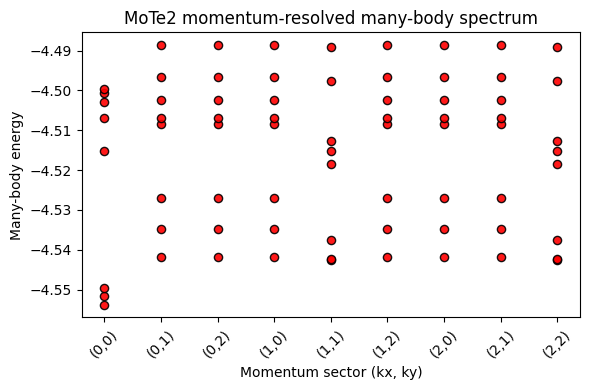

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(plot_x, plot_e, s=35, alpha=0.9, color="red", edgecolors="black")
ax.set_xticks(np.arange(len(plot_sectors)))
ax.set_xticklabels([f"({kx},{ky})" for (kx, ky) in plot_sectors], rotation=45)
ax.set_xlabel("Momentum sector (kx, ky)")
ax.set_ylabel("Many-body energy")
ax.set_title("MoTe2 momentum-resolved many-body spectrum")
plt.tight_layout()
plt.show()


In [32]:
-4.55376283 * 3

-13.66128849